# Feature-Based Model: Random Forest on ECG Morphological Features (All 12 Leads)

**Dataset:** Chapman-Shaoxing (AFib + Normal Sinus Rhythm subset)  
**Task:** Binary classification — AFib vs Normal  
**Model:** Random Forest on morphological features extracted via NeuroKit2  
**Input:** 12-lead ECG, 500 Hz, 10-second recordings  
**Setup:** 5-fold stratified CV by patient IDs (same split, seed=42)

### Feature Extraction Strategy:
- R-peak detection and wave delineation performed on **Lead II** (standard clinical practice)
- Morphological features (P-wave, R-peak, T-wave amplitudes) extracted from **all 12 leads** at the detected fiducial points
- Timing features (intervals, durations) extracted from Lead II

### Features (44 total):
- **Per lead (12 leads × 3 = 36):** P-wave amplitude, R-peak amplitude, T-wave amplitude
- **Lead II timing (8):** P-wave detection ratio, P-wave duration, QRS duration, PR interval, QT interval, Mean RR, Heart rate, Beat count


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install wfdb neurokit2 -q
print('Dependencies installed.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 120.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Dependencies installed.


## 1. Imports

In [2]:
import os
import numpy as np
import neurokit2 as nk
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

print(f"NeuroKit2 version: {nk.__version__}")
print("Imports done.")

NeuroKit2 version: 0.2.13
Imports done.


## 2. Configuration

In [3]:
class Config:
    afib_dir = ""
    normal_dir = ""

    fs = 500
    num_channels = 12
    recording_seconds = 10
    recording_samples = fs * recording_seconds
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    delineation_lead = 1  # Lead II index for R-peak detection and wave delineation

    n_estimators = 500
    class_weight = "balanced"
    n_jobs = -1

    n_folds = 5
    random_seed = 42

    pdf_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_rf_morphological"
    model_save_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model"

config = Config()
os.makedirs(config.pdf_dir, exist_ok=True)
os.makedirs(config.model_save_dir, exist_ok=True)
print("Config ready.")

Config ready.


## 3. Unzip Data

In [4]:
if not os.path.exists("/content/subset_data"):
    print("Unzipping subset...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/afib_normal_subset_ecg_arrhythmia.zip" -d /content/subset_data/

for base in ["/content/subset_data", "/content/subset_data/afib_normal_subset",
             "/content/subset_data/afib_normal_subset_ecg_arrhythmia"]:
    if os.path.exists(os.path.join(base, "afib")):
        config.afib_dir = os.path.join(base, "afib")
        config.normal_dir = os.path.join(base, "normal")
        break

print(f"AFib: {len([f for f in os.listdir(config.afib_dir) if f.endswith('.hea')])} records")
print(f"Normal: {len([f for f in os.listdir(config.normal_dir) if f.endswith('.hea')])} records")

Unzipping subset...
AFib: 1780 records
Normal: 8125 records


## 4. Discover Records

In [5]:
afib_files = sorted([f[:-4] for f in os.listdir(config.afib_dir) if f.endswith('.hea')])
normal_files = sorted([f[:-4] for f in os.listdir(config.normal_dir) if f.endswith('.hea')])

all_records = []
for name in afib_files:
    all_records.append({"path": os.path.join(config.afib_dir, name), "name": name, "label": 1})
for name in normal_files:
    all_records.append({"path": os.path.join(config.normal_dir, name), "name": name, "label": 0})

print(f"AFib: {len(afib_files)}, Normal: {len(normal_files)}, Total: {len(all_records)}")
print(f"AFib prevalence: {len(afib_files)/len(all_records):.2%}")

AFib: 1780, Normal: 8125, Total: 9905
AFib prevalence: 17.97%


## 5. Morphological Feature Extraction (All 12 Leads)

R-peak detection and wave delineation are performed on **Lead II** (standard clinical practice for rhythm analysis). Morphological features (amplitudes) are then extracted from **all 12 leads** at the detected fiducial points.

This approach ensures all leads contribute to the feature set while maintaining robust peak detection from the lead best suited for rhythm analysis.

In [6]:
def extract_morphological_features_12lead(signal, fs, config):
    """
    Extract ECG morphological features from all 12 leads.
    Wave delineation on Lead II, amplitudes from all leads.
    """
    try:
        # Step 1: Process Lead II for R-peaks and wave delineation
        lead2 = signal[:, config.delineation_lead]
        signals_ii, info_ii = nk.ecg_process(lead2, sampling_rate=fs)

        r_peaks = info_ii["ECG_R_Peaks"]
        n_beats = len(r_peaks)

        if n_beats < 3:
            return None

        # --- Get fiducial point indices from Lead II ---
        p_peak_indices = np.where(signals_ii["ECG_P_Peaks"].values == 1)[0]
        t_peak_indices = np.where(signals_ii["ECG_T_Peaks"].values == 1)[0]
        p_onset_indices = np.where(signals_ii["ECG_P_Onsets"].values == 1)[0]
        p_offset_indices = np.where(signals_ii["ECG_P_Offsets"].values == 1)[0]
        r_onset_indices = np.where(signals_ii["ECG_R_Onsets"].values == 1)[0]
        r_offset_indices = np.where(signals_ii["ECG_R_Offsets"].values == 1)[0]
        t_offset_indices = np.where(signals_ii["ECG_T_Offsets"].values == 1)[0]

        # --- Step 2: Extract amplitudes from ALL 12 leads ---
        # Clean each lead for amplitude extraction
        per_lead_features = []
        for ch in range(config.num_channels):
            try:
                clean_lead = nk.ecg_clean(signal[:, ch], sampling_rate=fs)
            except:
                clean_lead = signal[:, ch]

            # P-wave amplitude from this lead
            if len(p_peak_indices) > 0:
                p_amp = np.mean(clean_lead[p_peak_indices])
            else:
                p_amp = 0.0

            # R-peak amplitude from this lead
            r_amp = np.mean(clean_lead[r_peaks])

            # T-wave amplitude from this lead
            if len(t_peak_indices) > 0:
                t_amp = np.mean(clean_lead[t_peak_indices])
            else:
                t_amp = 0.0

            per_lead_features.extend([p_amp, r_amp, t_amp])

        # --- Step 3: Lead II timing features ---
        # RR intervals
        rr_intervals = np.diff(r_peaks) / fs
        mean_rr = np.mean(rr_intervals)
        heart_rate = 60.0 / mean_rr if mean_rr > 0 else 0

        # P-wave detection ratio
        p_detected_count = 0
        for rp in r_peaks:
            window_start = rp - int(0.3 * fs)
            window_end = rp - int(0.05 * fs)
            if window_start < 0:
                continue
            if np.any((p_peak_indices >= window_start) & (p_peak_indices <= window_end)):
                p_detected_count += 1
        p_wave_ratio = p_detected_count / n_beats

        # P-wave duration
        p_durations = []
        for onset in p_onset_indices:
            offsets_after = p_offset_indices[p_offset_indices > onset]
            if len(offsets_after) > 0:
                dur = (offsets_after[0] - onset) / fs * 1000
                if 20 < dur < 200:
                    p_durations.append(dur)
        mean_p_duration = np.mean(p_durations) if p_durations else 0.0

        # QRS duration
        qrs_durations = []
        for onset in r_onset_indices:
            offsets_after = r_offset_indices[r_offset_indices > onset]
            if len(offsets_after) > 0:
                dur = (offsets_after[0] - onset) / fs * 1000
                if 40 < dur < 200:
                    qrs_durations.append(dur)
        mean_qrs_duration = np.mean(qrs_durations) if qrs_durations else 0.0

        # PR interval
        pr_intervals = []
        for rp in r_peaks:
            window_start = rp - int(0.3 * fs)
            if window_start < 0:
                continue
            p_before = p_onset_indices[(p_onset_indices >= window_start) & (p_onset_indices < rp)]
            if len(p_before) > 0:
                pr_ms = (rp - p_before[-1]) / fs * 1000
                if 80 < pr_ms < 350:
                    pr_intervals.append(pr_ms)
        mean_pr_interval = np.mean(pr_intervals) if pr_intervals else 0.0

        # QT interval
        qt_intervals = []
        for onset in r_onset_indices:
            t_offs_after = t_offset_indices[t_offset_indices > onset]
            if len(t_offs_after) > 0:
                qt_ms = (t_offs_after[0] - onset) / fs * 1000
                if 200 < qt_ms < 600:
                    qt_intervals.append(qt_ms)
        mean_qt_interval = np.mean(qt_intervals) if qt_intervals else 0.0

        # --- Assemble feature vector ---
        timing_features = [
            p_wave_ratio, mean_p_duration, mean_qrs_duration,
            mean_pr_interval, mean_qt_interval,
            mean_rr, heart_rate, n_beats
        ]

        features = np.array(per_lead_features + timing_features, dtype=np.float32)

        if np.any(np.isnan(features)) or np.any(np.isinf(features)):
            features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

        return features

    except Exception:
        return None


# Build feature names
feature_names = []
for lead in config.lead_names:
    feature_names.append(f"{lead}_P_Amplitude")
    feature_names.append(f"{lead}_R_Amplitude")
    feature_names.append(f"{lead}_T_Amplitude")
feature_names.extend([
    'P_Wave_Ratio', 'P_Wave_Duration_ms', 'QRS_Duration_ms',
    'PR_Interval_ms', 'QT_Interval_ms',
    'Mean_RR_s', 'Heart_Rate_bpm', 'Beat_Count'
])

print(f"Total features: {len(feature_names)}")
print(f"  Per-lead features: {config.num_channels} leads x 3 (P, R, T amplitudes) = {config.num_channels * 3}")
print(f"  Lead II timing features: 8")
print(f"\nFeature list:")
for i, name in enumerate(feature_names):
    print(f"  {i+1:2d}. {name}")

Total features: 44
  Per-lead features: 12 leads x 3 (P, R, T amplitudes) = 36
  Lead II timing features: 8

Feature list:
   1. I_P_Amplitude
   2. I_R_Amplitude
   3. I_T_Amplitude
   4. II_P_Amplitude
   5. II_R_Amplitude
   6. II_T_Amplitude
   7. III_P_Amplitude
   8. III_R_Amplitude
   9. III_T_Amplitude
  10. aVR_P_Amplitude
  11. aVR_R_Amplitude
  12. aVR_T_Amplitude
  13. aVL_P_Amplitude
  14. aVL_R_Amplitude
  15. aVL_T_Amplitude
  16. aVF_P_Amplitude
  17. aVF_R_Amplitude
  18. aVF_T_Amplitude
  19. V1_P_Amplitude
  20. V1_R_Amplitude
  21. V1_T_Amplitude
  22. V2_P_Amplitude
  23. V2_R_Amplitude
  24. V2_T_Amplitude
  25. V3_P_Amplitude
  26. V3_R_Amplitude
  27. V3_T_Amplitude
  28. V4_P_Amplitude
  29. V4_R_Amplitude
  30. V4_T_Amplitude
  31. V5_P_Amplitude
  32. V5_R_Amplitude
  33. V5_T_Amplitude
  34. V6_P_Amplitude
  35. V6_R_Amplitude
  36. V6_T_Amplitude
  37. P_Wave_Ratio
  38. P_Wave_Duration_ms
  39. QRS_Duration_ms
  40. PR_Interval_ms
  41. QT_Interval_ms
  42

## 6. Extract Features from All Records

In [7]:
print(f"Extracting morphological features (12 leads) from {len(all_records)} records...")
start_time = time.time()

patient_features = {}
skipped = 0
skip_reasons = {"read_error": 0, "extraction_failed": 0}

for i, rec in enumerate(all_records):
    if (i + 1) % 500 == 0:
        elapsed = time.time() - start_time
        pct = (i + 1) / len(all_records) * 100
        est_total = elapsed / (i + 1) * len(all_records)
        est_remaining = est_total - elapsed
        print(f"  Processed {i+1}/{len(all_records)} ({pct:.0f}%) [{elapsed/60:.1f} min elapsed, ~{est_remaining/60:.1f} min remaining]")

    try:
        record = wfdb.rdrecord(rec["path"])
        signal = record.p_signal

        if signal.shape[1] < config.num_channels or np.any(np.isnan(signal)):
            skipped += 1
            skip_reasons["read_error"] += 1
            continue

        if len(signal) < config.recording_samples:
            signal = np.vstack([signal, np.zeros((config.recording_samples - len(signal), config.num_channels))])
        elif len(signal) > config.recording_samples:
            signal = signal[:config.recording_samples, :]

        features = extract_morphological_features_12lead(signal, config.fs, config)

        if features is None:
            skipped += 1
            skip_reasons["extraction_failed"] += 1
            continue

        patient_features[rec["name"]] = {"features": features, "label": rec["label"]}

    except Exception:
        skipped += 1
        skip_reasons["read_error"] += 1

load_time = time.time() - start_time
print(f"\nExtraction complete in {load_time/60:.1f} minutes")
print(f"Patients loaded: {len(patient_features)} (skipped: {skipped})")
print(f"  Skip reasons: {skip_reasons}")

afib_patients = sum(1 for p in patient_features.values() if p["label"] == 1)
normal_patients = sum(1 for p in patient_features.values() if p["label"] == 0)
print(f"  AFib: {afib_patients}, Normal: {normal_patients}")

Extracting morphological features (12 leads) from 9905 records...
  Processed 500/9905 (5%) [1.5 min elapsed, ~27.7 min remaining]
  Processed 1000/9905 (10%) [2.9 min elapsed, ~26.2 min remaining]
  Processed 1500/9905 (15%) [4.4 min elapsed, ~24.7 min remaining]
  Processed 2000/9905 (20%) [5.8 min elapsed, ~23.0 min remaining]
  Processed 2500/9905 (25%) [7.2 min elapsed, ~21.3 min remaining]
  Processed 3000/9905 (30%) [8.5 min elapsed, ~19.7 min remaining]
  Processed 3500/9905 (35%) [9.9 min elapsed, ~18.1 min remaining]
  Processed 4000/9905 (40%) [11.3 min elapsed, ~16.7 min remaining]
  Processed 4500/9905 (45%) [12.7 min elapsed, ~15.2 min remaining]
  Processed 5000/9905 (50%) [14.0 min elapsed, ~13.7 min remaining]
  Processed 5500/9905 (56%) [15.4 min elapsed, ~12.3 min remaining]
  Processed 6000/9905 (61%) [16.7 min elapsed, ~10.9 min remaining]
  Processed 6500/9905 (66%) [18.0 min elapsed, ~9.5 min remaining]
  Processed 7000/9905 (71%) [19.4 min elapsed, ~8.0 min rema

## 7. 5-Fold Stratified Split (Same seed=42)

In [8]:
np.random.seed(config.random_seed)
patient_names = np.array(sorted(patient_features.keys()))
patient_labels = np.array([patient_features[p]["label"] for p in patient_names])

skf = StratifiedKFold(n_splits=config.n_folds, shuffle=True, random_state=config.random_seed)
folds = []

print("=" * 80)
print("5-FOLD SPLIT (same seed=42)")
print("=" * 80)
print(f"{'Fold':<6} {'Train':<10} {'Val':<10} {'Val AFib':<12} {'Val Normal':<12} {'AFib %'}")
print("-" * 60)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(patient_names, patient_labels)):
    train_p = patient_names[train_idx].tolist()
    val_p = patient_names[val_idx].tolist()
    folds.append({"train": train_p, "val": val_p})
    va = sum(1 for p in val_p if patient_features[p]["label"] == 1)
    vn = sum(1 for p in val_p if patient_features[p]["label"] == 0)
    print(f"{fold_idx+1:<6} {len(train_p):<10} {len(val_p):<10} {va:<12} {vn:<12} {va/(va+vn)*100:.1f}%")

5-FOLD SPLIT (same seed=42)
Fold   Train      Val        Val AFib     Val Normal   AFib %
------------------------------------------------------------
1      7906       1977       356          1621         18.0%
2      7906       1977       356          1621         18.0%
3      7906       1977       355          1622         18.0%
4      7907       1976       355          1621         18.0%
5      7907       1976       355          1621         18.0%


## 8. Helper Functions

In [9]:
def merge_patients(patient_list):
    X = np.array([patient_features[p]["features"] for p in patient_list], dtype=np.float32)
    y = np.array([patient_features[p]["label"] for p in patient_list], dtype=np.int64)
    return X, y

def compute_all_metrics(targets, preds, probs):
    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    brier = brier_score_loss(targets, probs)
    n_bins = 10
    boundaries = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    for i in range(n_bins):
        mask = (probs >= boundaries[i]) & (probs < boundaries[i+1]) if i < n_bins-1 else (probs >= boundaries[i]) & (probs <= boundaries[i+1])
        if mask.sum() > 0:
            err = abs(targets[mask].mean() - probs[mask].mean())
            ece += (mask.sum() / len(targets)) * err
            mce = max(mce, err)
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "accuracy": accuracy_score(targets, preds),
            "precision": precision_score(targets, preds, zero_division=0),
            "recall": recall_score(targets, preds, zero_division=0),
            "f1": f1_score(targets, preds, zero_division=0),
            "mcc": matthews_corrcoef(targets, preds),
            "auroc": roc_auc_score(targets, probs),
            "auprc": average_precision_score(targets, probs),
            "brier": brier, "ece": ece, "mce": mce, "cm": cm}

print("Functions defined.")

Functions defined.


## 9. Run 5-Fold CV (Random Forest)

In [10]:
all_fold_metrics = []
all_fold_targets = []
all_fold_preds = []
all_fold_probs = []
all_fold_models = []

total_start = time.time()

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx+1}/{config.n_folds}")
    print(f"{'='*60}")

    X_train, y_train = merge_patients(fold["train"])
    X_val, y_val = merge_patients(fold["val"])
    print(f"  Train: {len(y_train)} (AFib: {np.sum(y_train==1)}, Normal: {np.sum(y_train==0)})")
    print(f"  Val:   {len(y_val)} (AFib: {np.sum(y_val==1)}, Normal: {np.sum(y_val==0)})")
    print(f"  Features: {X_train.shape[1]}")

    rf = RandomForestClassifier(
        n_estimators=config.n_estimators,
        class_weight=config.class_weight,
        random_state=config.random_seed,
        n_jobs=config.n_jobs
    )
    rf.fit(X_train, y_train)

    preds = rf.predict(X_val)
    probs = rf.predict_proba(X_val)[:, 1]
    metrics = compute_all_metrics(y_val, preds, probs)

    all_fold_metrics.append(metrics)
    all_fold_targets.append(y_val)
    all_fold_preds.append(preds)
    all_fold_probs.append(probs)
    all_fold_models.append(rf)

    print(f"  Acc={metrics['accuracy']:.4f} F1={metrics['f1']:.4f} Recall={metrics['recall']:.4f} AUROC={metrics['auroc']:.4f}")
    print(f"  TN={metrics['tn']} FP={metrics['fp']} FN={metrics['fn']} TP={metrics['tp']}")
    print(f"  ECE={metrics['ece']:.4f} MCE={metrics['mce']:.4f} Brier={metrics['brier']:.4f}")

total_time = time.time() - total_start
print(f"\nTotal CV time: {total_time:.1f} seconds")


FOLD 1/5
  Train: 7906 (AFib: 1421, Normal: 6485)
  Val:   1977 (AFib: 356, Normal: 1621)
  Features: 44
  Acc=0.9525 F1=0.8597 Recall=0.8090 AUROC=0.9893
  TN=1595 FP=26 FN=68 TP=288
  ECE=0.0429 MCE=0.2449 Brier=0.0357

FOLD 2/5
  Train: 7906 (AFib: 1421, Normal: 6485)
  Val:   1977 (AFib: 356, Normal: 1621)
  Features: 44
  Acc=0.9418 F1=0.8239 Recall=0.7556 AUROC=0.9810
  TN=1593 FP=28 FN=87 TP=269
  ECE=0.0329 MCE=0.2032 Brier=0.0423

FOLD 3/5
  Train: 7906 (AFib: 1422, Normal: 6484)
  Val:   1977 (AFib: 355, Normal: 1622)
  Features: 44
  Acc=0.9439 F1=0.8311 Recall=0.7690 AUROC=0.9849
  TN=1593 FP=29 FN=82 TP=273
  ECE=0.0406 MCE=0.2733 Brier=0.0398

FOLD 4/5
  Train: 7907 (AFib: 1422, Normal: 6485)
  Val:   1976 (AFib: 355, Normal: 1621)
  Features: 44
  Acc=0.9509 F1=0.8510 Recall=0.7803 AUROC=0.9889
  TN=1602 FP=19 FN=78 TP=277
  ECE=0.0427 MCE=0.3393 Brier=0.0378

FOLD 5/5
  Train: 7907 (AFib: 1422, Normal: 6485)
  Val:   1976 (AFib: 355, Normal: 1621)
  Features: 44
  Acc=

## 10. Results Summary

In [11]:
metric_names = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce"]

print("=" * 100)
print("5-FOLD CV RESULTS — RF on Morphological Features (All 12 Leads, NeuroKit2)")
print("=" * 100)
header = f"{'Metric':<12}"
for i in range(len(folds)): header += f"{'Fold '+str(i+1):<14}"
header += f"{'Mean':<14}{'Std':<14}"
print(header)
print("-" * 100)

for metric in metric_names + ["tn", "fp", "fn", "tp"]:
    values = [m[metric] for m in all_fold_metrics]
    row = f"{metric.upper():<12}"
    for v in values:
        row += f"{int(v):<14}" if metric in ["tn","fp","fn","tp"] else f"{v:<14.4f}"
    mean_v, std_v = np.mean(values), np.std(values)
    row += f"{mean_v:<14.0f}{std_v:<14.0f}" if metric in ["tn","fp","fn","tp"] else f"{mean_v:<14.4f}{std_v:<14.4f}"
    print(row)
print("=" * 100)

5-FOLD CV RESULTS — RF on Morphological Features (All 12 Leads, NeuroKit2)
Metric      Fold 1        Fold 2        Fold 3        Fold 4        Fold 5        Mean          Std           
----------------------------------------------------------------------------------------------------
ACCURACY    0.9525        0.9418        0.9439        0.9509        0.9479        0.9474        0.0040        
PRECISION   0.9172        0.9057        0.9040        0.9358        0.9013        0.9128        0.0127        
RECALL      0.8090        0.7556        0.7690        0.7803        0.7972        0.7822        0.0191        
F1          0.8597        0.8239        0.8311        0.8510        0.8460        0.8423        0.0131        
MCC         0.8336        0.7940        0.8014        0.8268        0.8170        0.8146        0.0149        
AUROC       0.9893        0.9810        0.9849        0.9889        0.9847        0.9858        0.0031        
AUPRC       0.9519        0.9288        0.9358 

## 11. Feature Importance (Top 20)

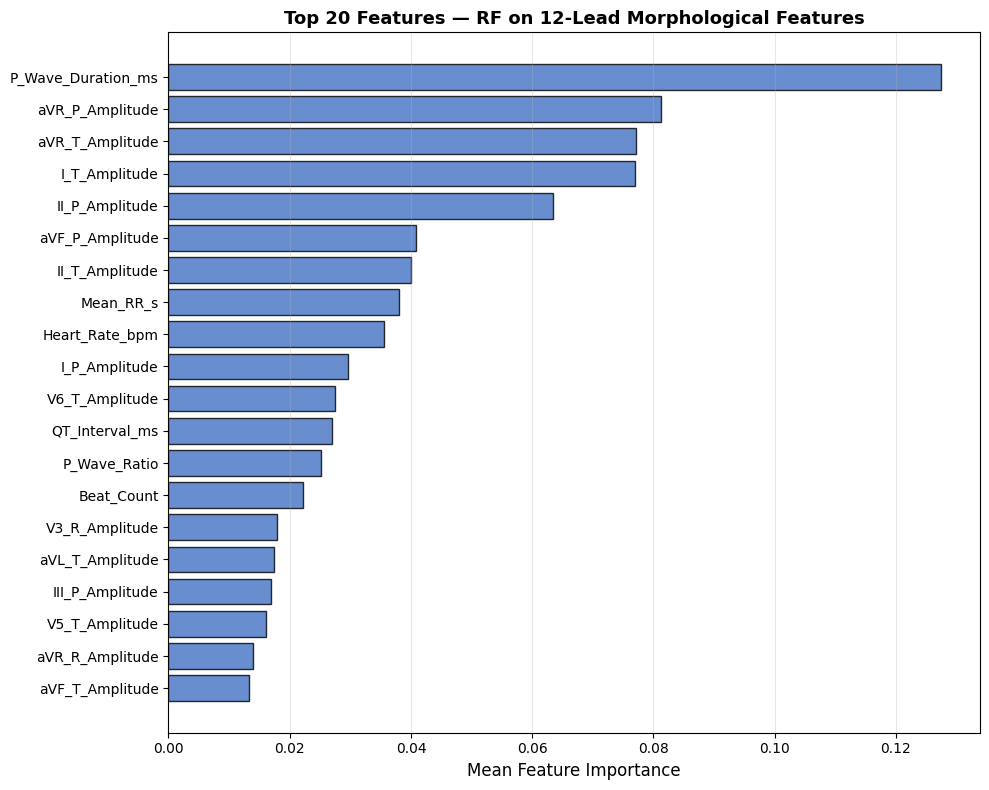


Feature importance ranking (all features):
   1. P_Wave_Duration_ms        0.1275
   2. aVR_P_Amplitude           0.0812
   3. aVR_T_Amplitude           0.0771
   4. I_T_Amplitude             0.0770
   5. II_P_Amplitude            0.0635
   6. aVF_P_Amplitude           0.0408
   7. II_T_Amplitude            0.0400
   8. Mean_RR_s                 0.0381
   9. Heart_Rate_bpm            0.0355
  10. I_P_Amplitude             0.0296
  11. V6_T_Amplitude            0.0275
  12. QT_Interval_ms            0.0269
  13. P_Wave_Ratio              0.0251
  14. Beat_Count                0.0222
  15. V3_R_Amplitude            0.0179
  16. aVL_T_Amplitude           0.0173
  17. III_P_Amplitude           0.0169
  18. V5_T_Amplitude            0.0161
  19. aVR_R_Amplitude           0.0140
  20. aVF_T_Amplitude           0.0133
  21. V6_P_Amplitude            0.0118
  22. V5_P_Amplitude            0.0108
  23. V6_R_Amplitude            0.0107
  24. V4_P_Amplitude            0.0106
  25. aVL_P_Amplitud

In [12]:
mean_imp = np.mean([rf.feature_importances_ for rf in all_fold_models], axis=0)
sorted_idx = np.argsort(mean_imp)[::-1]
top_n = min(20, len(feature_names))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), mean_imp[sorted_idx[:top_n]][::-1], color='#4472C4', edgecolor='black', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]][::-1], fontsize=10)
ax.set_xlabel('Mean Feature Importance', fontsize=12)
ax.set_title('Top 20 Features — RF on 12-Lead Morphological Features', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "rf_morph_feature_importance.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

print("\nFeature importance ranking (all features):")
for rank, idx in enumerate(sorted_idx):
    print(f"  {rank+1:2d}. {feature_names[idx]:<25s} {mean_imp[idx]:.4f}")

## 12. Confusion Matrices

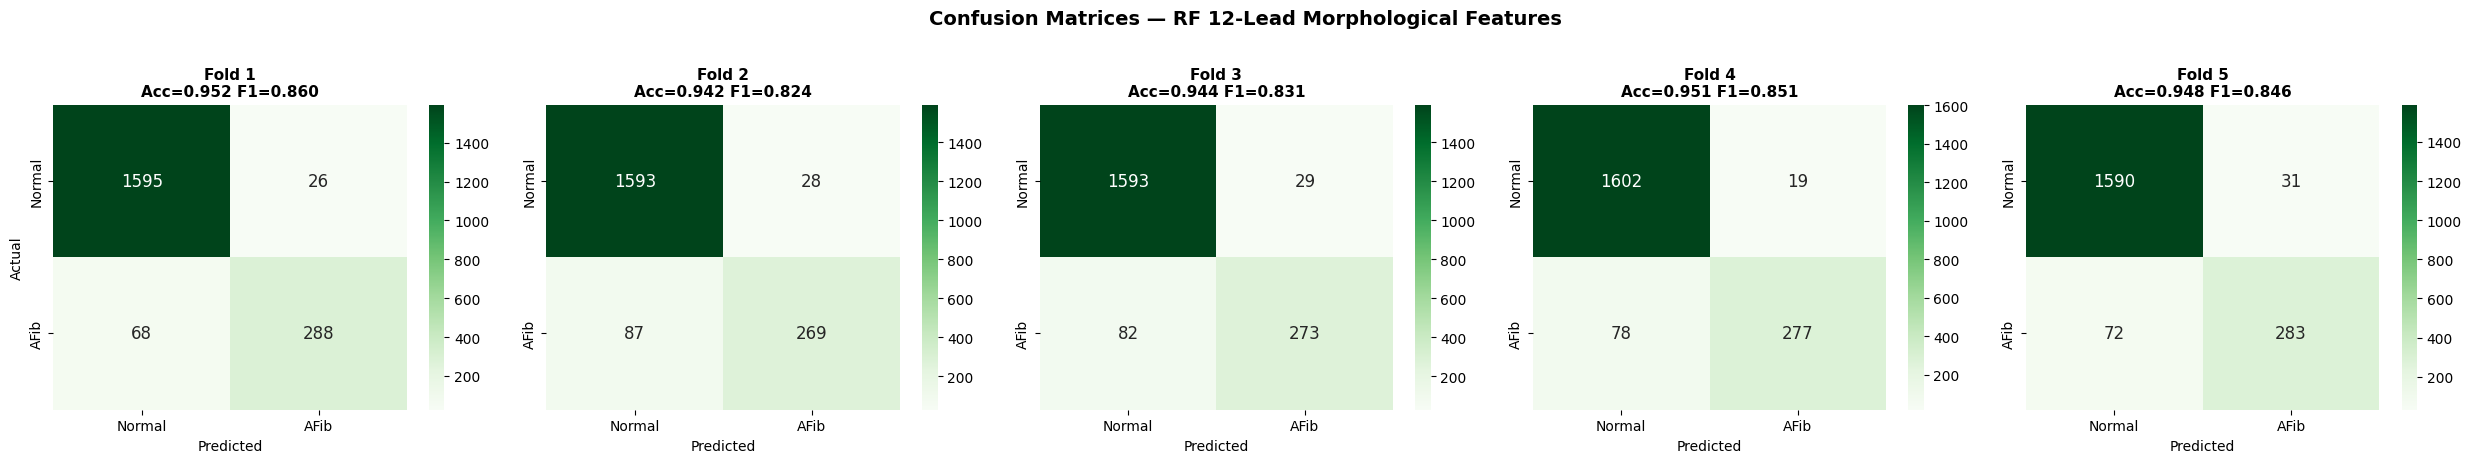

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for i, m in enumerate(all_fold_metrics):
    ax = axes[i]
    sns.heatmap(m["cm"], annot=True, fmt="d", cmap="Greens",
                xticklabels=["Normal","AFib"], yticklabels=["Normal","AFib"], ax=ax, annot_kws={"size":12})
    ax.set_title(f"Fold {i+1}\nAcc={m['accuracy']:.3f} F1={m['f1']:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual" if i==0 else "")
plt.suptitle("Confusion Matrices — RF 12-Lead Morphological Features", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "rf_morph_confusion_matrices.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 13. ROC Curves

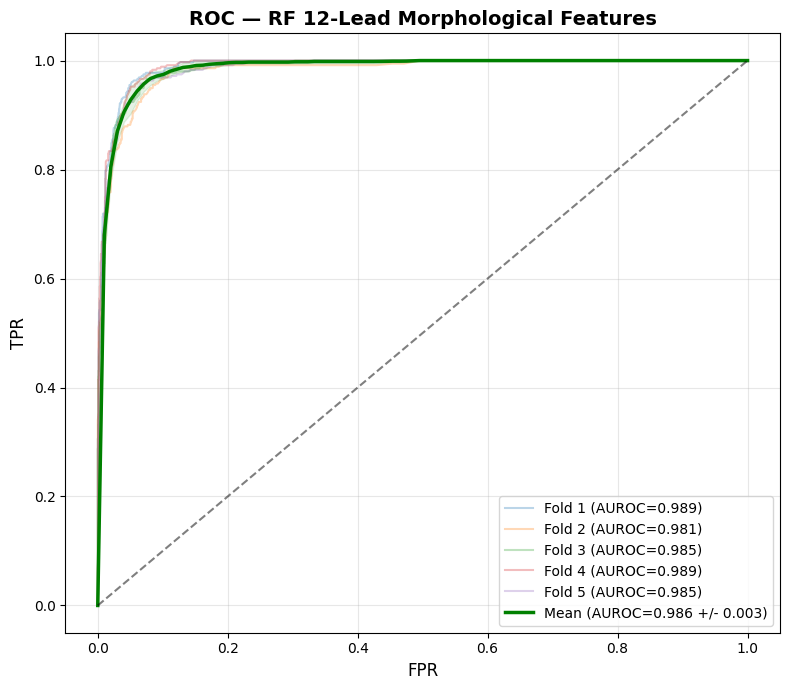

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_fpr = np.linspace(0, 1, 100)
tprs = []
for i in range(len(folds)):
    fpr, tpr, _ = roc_curve(all_fold_targets[i], all_fold_probs[i])
    ax.plot(fpr, tpr, alpha=0.3, linewidth=1.5, label=f'Fold {i+1} (AUROC={all_fold_metrics[i]["auroc"]:.3f})')
    t = np.interp(mean_fpr, fpr, tpr); t[0] = 0.0; tprs.append(t)
mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
mean_auroc = np.mean([m["auroc"] for m in all_fold_metrics])
std_auroc = np.std([m["auroc"] for m in all_fold_metrics])
ax.plot(mean_fpr, mean_tpr, color='green', linewidth=2.5, label=f'Mean (AUROC={mean_auroc:.3f} +/- {std_auroc:.3f})')
ax.fill_between(mean_fpr, np.maximum(np.mean(tprs,0)-np.std(tprs,0),0), np.minimum(np.mean(tprs,0)+np.std(tprs,0),1), color='green', alpha=0.1)
ax.plot([0,1],[0,1],'k--',alpha=0.5)
ax.set_xlabel('FPR', fontsize=12); ax.set_ylabel('TPR', fontsize=12)
ax.set_title('ROC — RF 12-Lead Morphological Features', fontsize=14, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "rf_morph_roc_curves.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 14. Precision-Recall Curves

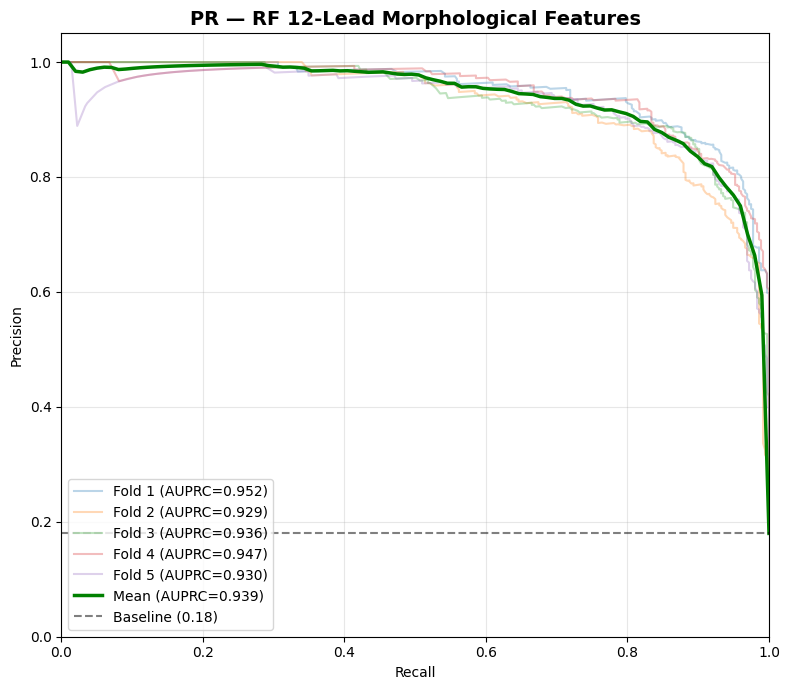

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_rec_pts = np.linspace(0, 1, 100)
precs = []
for i in range(len(folds)):
    p, r, _ = precision_recall_curve(all_fold_targets[i], all_fold_probs[i])
    ax.plot(r, p, alpha=0.3, linewidth=1.5, label=f'Fold {i+1} (AUPRC={all_fold_metrics[i]["auprc"]:.3f})')
    precs.append(np.interp(mean_rec_pts, r[::-1], p[::-1]))
mean_p = np.mean(precs, axis=0)
mean_auprc = np.mean([m["auprc"] for m in all_fold_metrics])
ax.plot(mean_rec_pts, mean_p, color='green', linewidth=2.5, label=f'Mean (AUPRC={mean_auprc:.3f})')
baseline = np.mean(np.concatenate(all_fold_targets))
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR — RF 12-Lead Morphological Features', fontsize=14, fontweight='bold')
ax.legend(loc='lower left'); ax.grid(True, alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "rf_morph_pr_curves.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 15. Calibration Plots

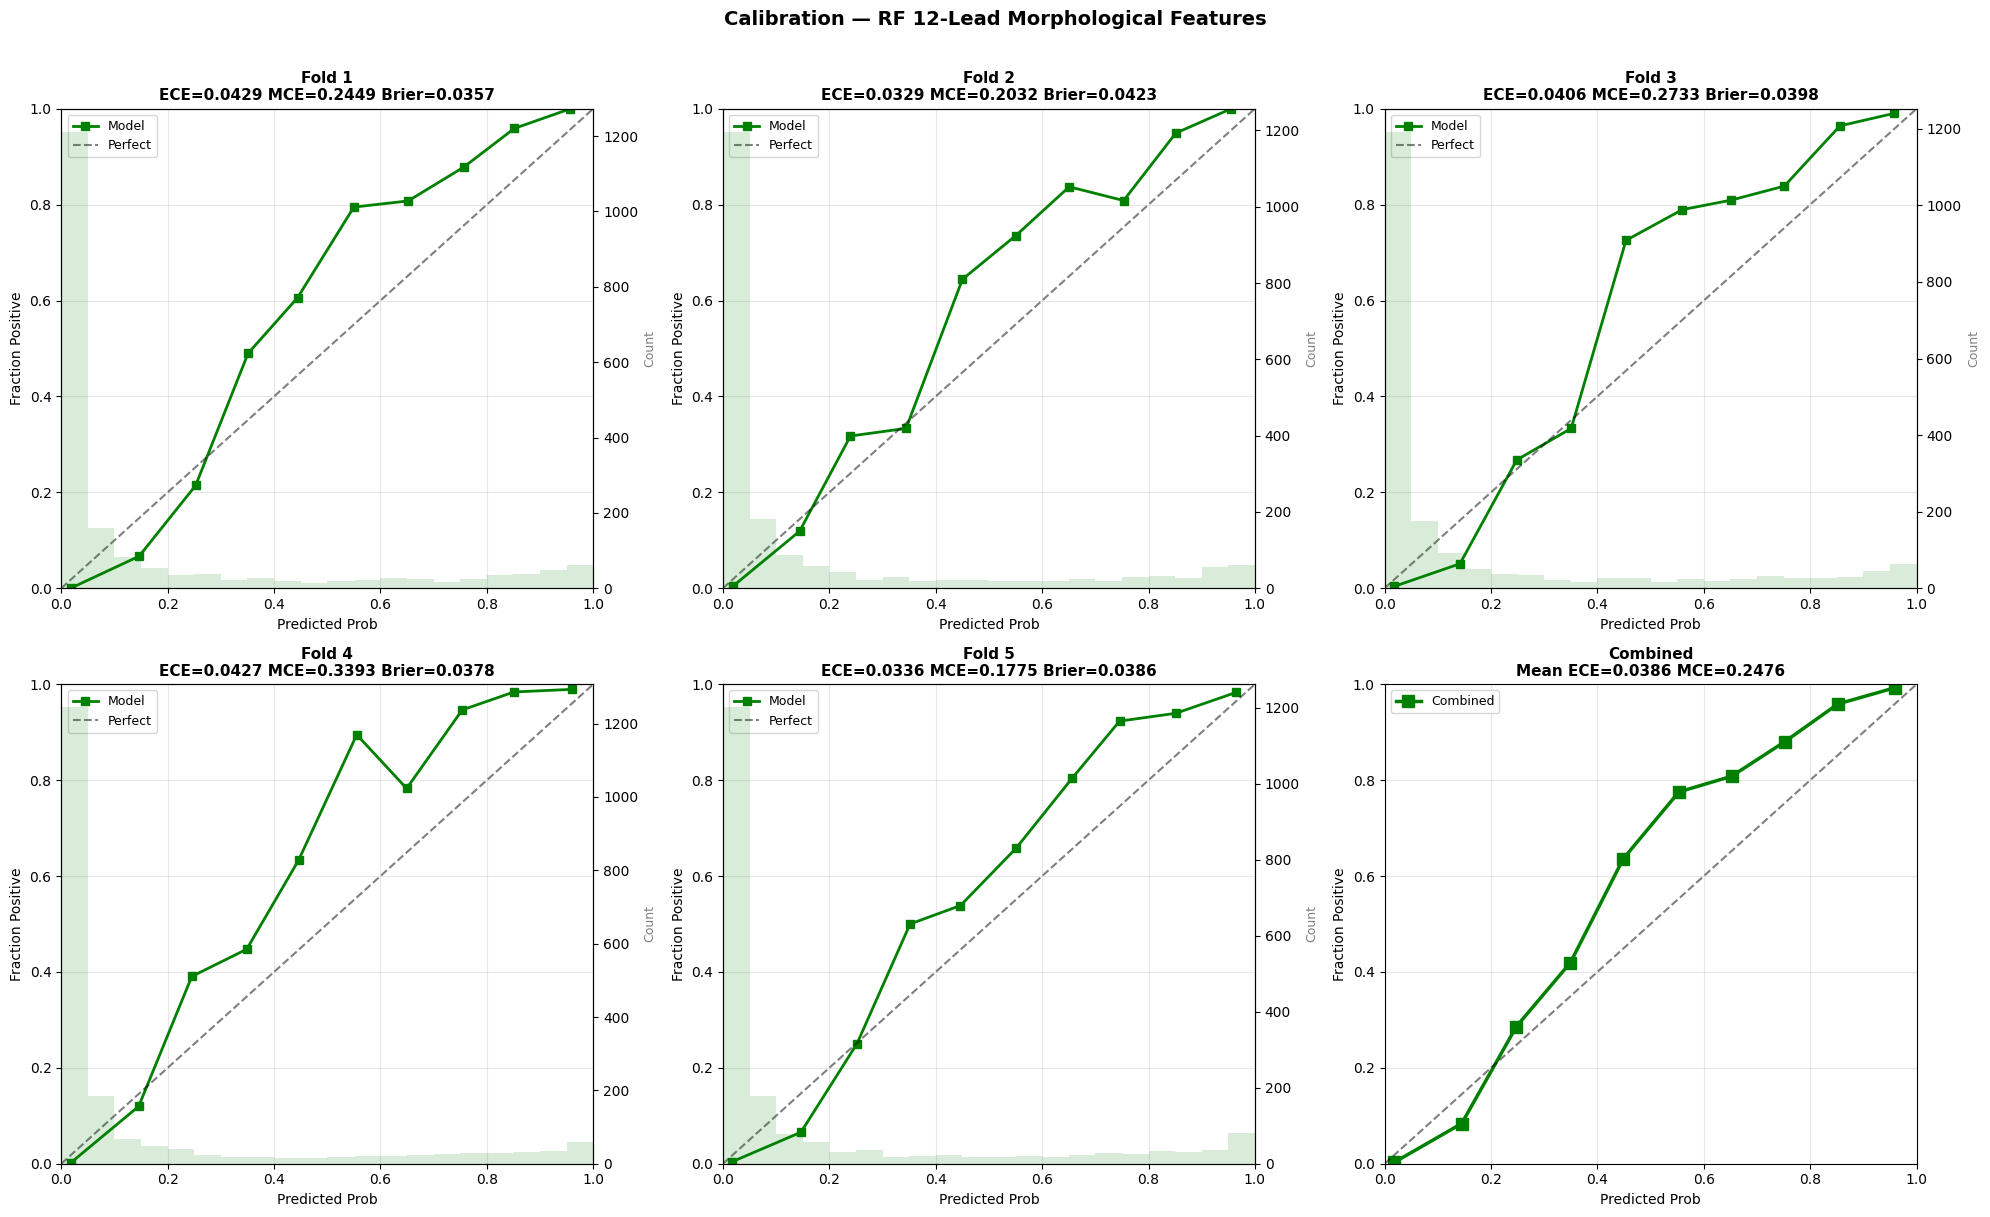

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for i in range(len(folds)):
    row, col = i // 3, i % 3
    ax = axes[row][col]
    frac, pred = calibration_curve(all_fold_targets[i], all_fold_probs[i], n_bins=10, strategy='uniform')
    ax.plot(pred, frac, 's-', color='green', linewidth=2, markersize=6, label='Model')
    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(all_fold_probs[i], bins=20, range=(0,1), alpha=0.15, color='green')
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    m = all_fold_metrics[i]
    ax.set_title(f"Fold {i+1}\nECE={m['ece']:.4f} MCE={m['mce']:.4f} Brier={m['brier']:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Prob'); ax.set_ylabel('Fraction Positive')
    ax.legend(loc='upper left',fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True,alpha=0.3)

ax = axes[1][2]
all_t = np.concatenate(all_fold_targets); all_p = np.concatenate(all_fold_probs)
frac, pred = calibration_curve(all_t, all_p, n_bins=10, strategy='uniform')
ax.plot(pred, frac, 's-', color='green', linewidth=2.5, markersize=8, label='Combined')
ax.plot([0,1],[0,1],'k--',alpha=0.5)
mean_ece = np.mean([m['ece'] for m in all_fold_metrics])
mean_mce = np.mean([m['mce'] for m in all_fold_metrics])
ax.set_title(f"Combined\nMean ECE={mean_ece:.4f} MCE={mean_mce:.4f}", fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Prob'); ax.set_ylabel('Fraction Positive')
ax.legend(loc='upper left',fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True,alpha=0.3)
plt.suptitle("Calibration — RF 12-Lead Morphological Features", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "rf_morph_calibration_plots.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 16. Probability Distributions

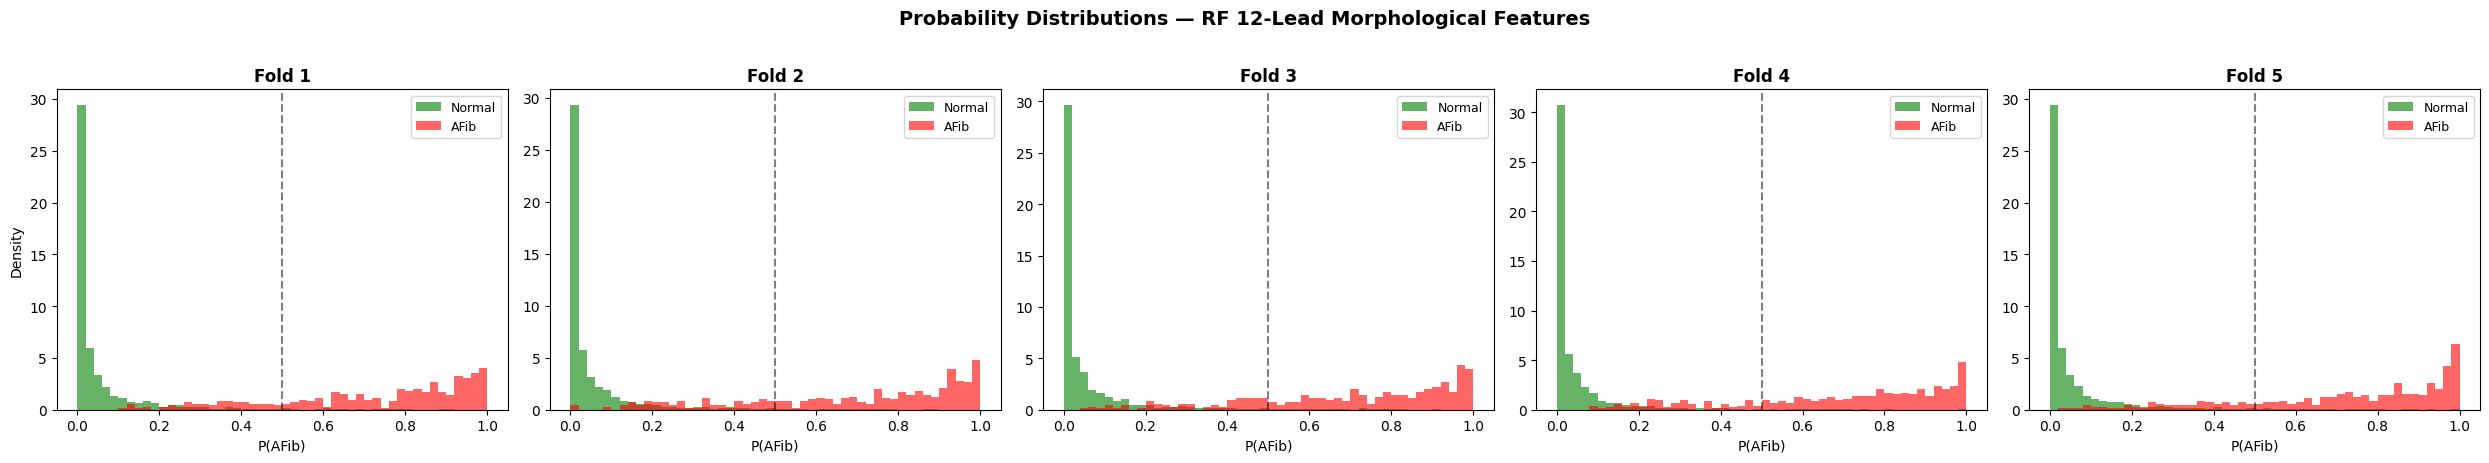

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for i in range(len(folds)):
    ax = axes[i]
    ax.hist(all_fold_probs[i][all_fold_targets[i]==0], bins=50, range=(0,1), alpha=0.6, color='green', label='Normal', density=True)
    ax.hist(all_fold_probs[i][all_fold_targets[i]==1], bins=50, range=(0,1), alpha=0.6, color='red', label='AFib', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"Fold {i+1}", fontweight='bold'); ax.set_xlabel("P(AFib)")
    if i==0: ax.set_ylabel("Density")
    ax.legend(fontsize=9)
plt.suptitle("Probability Distributions — RF 12-Lead Morphological Features", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "rf_morph_probability_distributions.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 17. Comparison: All Models

In [18]:
print("=" * 80)
print("COMPARISON: All Models on Chapman-Shaoxing")
print("=" * 80)
print(f"\n{'Metric':<12} {'KanResWideX':<15} {'CNN-BiLSTM':<15} {'RF (Morph)':<15}")
print("-" * 57)

kanres = {"accuracy":0.9952,"precision":0.9823,"recall":0.9916,"f1":0.9869,"mcc":0.9840,
          "auroc":0.9991,"auprc":0.9941,"brier":0.0042,"ece":0.0038,"mce":0.5373}
bilstm = {"accuracy":0.9903,"precision":0.9577,"recall":0.9899,"f1":0.9735,"mcc":0.9678,
          "auroc":0.9983,"auprc":0.9895,"brier":0.0082,"ece":0.0072,"mce":0.5204}

for metric in ["accuracy","precision","recall","f1","mcc","auroc","auprc","brier","ece","mce"]:
    rf_m = np.mean([m[metric] for m in all_fold_metrics])
    print(f"{metric.upper():<12} {kanres[metric]:<15.4f} {bilstm[metric]:<15.4f} {rf_m:<15.4f}")

COMPARISON: All Models on Chapman-Shaoxing

Metric       KanResWideX     CNN-BiLSTM      RF (Morph)     
---------------------------------------------------------
ACCURACY     0.9952          0.9903          0.9474         
PRECISION    0.9823          0.9577          0.9128         
RECALL       0.9916          0.9899          0.7822         
F1           0.9869          0.9735          0.8423         
MCC          0.9840          0.9678          0.8146         
AUROC        0.9991          0.9983          0.9858         
AUPRC        0.9941          0.9895          0.9388         
BRIER        0.0042          0.0082          0.0389         
ECE          0.0038          0.0072          0.0386         
MCE          0.5373          0.5204          0.2476         


## 18. Final Summary

In [19]:
print("=" * 70)
print("FINAL SUMMARY — RF on 12-Lead Morphological Features (NeuroKit2)")
print("=" * 70)
print()
for m in ["accuracy","precision","recall","f1","mcc","auroc","auprc","brier","ece","mce"]:
    mean_v = np.mean([f[m] for f in all_fold_metrics])
    std_v = np.std([f[m] for f in all_fold_metrics])
    print(f"  {m.upper():<15} {mean_v:.4f} +/- {std_v:.4f}")
print()
print(f"Model: Random Forest ({config.n_estimators} trees, class_weight=balanced)")
print(f"Features: {len(feature_names)} morphological ({config.num_channels} leads x 3 amplitudes + 8 timing)")
print(f"Delineation: Lead II (NeuroKit2), amplitudes from all 12 leads")
print(f"Patients: {len(patient_features)} (AFib: {afib_patients}, Normal: {normal_patients})")
print(f"CV time: {total_time:.1f} seconds")

FINAL SUMMARY — RF on 12-Lead Morphological Features (NeuroKit2)

  ACCURACY        0.9474 +/- 0.0040
  PRECISION       0.9128 +/- 0.0127
  RECALL          0.7822 +/- 0.0191
  F1              0.8423 +/- 0.0131
  MCC             0.8146 +/- 0.0149
  AUROC           0.9858 +/- 0.0031
  AUPRC           0.9388 +/- 0.0093
  BRIER           0.0389 +/- 0.0022
  ECE             0.0386 +/- 0.0044
  MCE             0.2476 +/- 0.0565

Model: Random Forest (500 trees, class_weight=balanced)
Features: 44 morphological (12 leads x 3 amplitudes + 8 timing)
Delineation: Lead II (NeuroKit2), amplitudes from all 12 leads
Patients: 9883 (AFib: 1777, Normal: 8106)
CV time: 18.7 seconds


## 19. Save Best Model

In [20]:
best_idx = np.argmax([m["f1"] for m in all_fold_metrics])
print(f"Best fold: {best_idx+1} (F1={all_fold_metrics[best_idx]['f1']:.4f})")

save_path = os.path.join(config.model_save_dir, "best_rf_morphological_model.pkl")
with open(save_path, 'wb') as f:
    pickle.dump(all_fold_models[best_idx], f)
print(f"Model saved: {save_path}")

feat_path = os.path.join(config.model_save_dir, "rf_morphological_feature_names.pkl")
with open(feat_path, 'wb') as f:
    pickle.dump(feature_names, f)
print(f"Feature names saved: {feat_path}")

print(f"\nPDFs in: {config.pdf_dir}")
for fn in sorted(os.listdir(config.pdf_dir)):
    if fn.endswith('.pdf'): print(f"  {fn}")

Best fold: 1 (F1=0.8597)
Model saved: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_rf_morphological_model.pkl
Feature names saved: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/rf_morphological_feature_names.pkl

PDFs in: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_rf_morphological
  rf_morph_calibration_plots.pdf
  rf_morph_confusion_matrices.pdf
  rf_morph_feature_importance.pdf
  rf_morph_pr_curves.pdf
  rf_morph_probability_distributions.pdf
  rf_morph_roc_curves.pdf
